# Project#1 AI기반 산불 예측 서비스 개발

### 학번 : 2021810018
### 이름 : 김조현

## 1-1 Data 불러오기

In [1]:
import sys
import sklearn
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

In [3]:
fires = pd.read_csv("/Users/kimjohyeon/Desktop/sanbul-web-service/sanbul-5.csv", sep=',')

## 1-2 fires.head(), fires.info(), fires.describe(), 카테고리형 특성 month, day에 대해 value_counts() 출력하기

In [4]:
fires.head()

,latitude,longitude,month,day,avg_temp,max_temp,max_wind_speed,avg_wind,burned_area
0,37.814760,126.934555,12-Dec,04-thu,-11.2,-7.5,8.4,2.3,0.03
1,37.902374,127.531013,11-Nov,02-tue,2.6,11.2,5.9,0.8,0.10
2,37.815010,127.303115,03-Mar,05-fri,13.2,21.5,5.7,1.3,0.50
3,37.645414,127.504775,02-Feb,06-sat,-4.0,1.1,10.4,2.5,0.30
4,37.811693,127.514488,06-Jun,00-sun,23.0,32.1,6.7,1.7,0.08


In [5]:
fires.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456 entries, 0 to 455
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   latitude        456 non-null    float64
 1   longitude       456 non-null    float64
 2   month           456 non-null    object 
 3   day             456 non-null    object 
 4   avg_temp        456 non-null    float64
 5   max_temp        456 non-null    float64
 6   max_wind_speed  456 non-null    float64
 7   avg_wind        456 non-null    float64
 8   burned_area     456 non-null    float64
dtypes: float64(7), object(2)
memory usage: 32.2+ KB


In [6]:
fires.describe()

,latitude,longitude,avg_temp,max_temp,max_wind_speed,avg_wind,burned_area
count,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000
mean,37.554922,127.152073,9.810088,17.717763,7.692982,1.601316,0.282675
std,0.289899,0.267260,8.278386,8.878393,2.073081,0.581168,0.596268
min,36.878411,126.447779,-15.400000,-10.600000,3.600000,0.500000,0.010000
25%,37.339854,126.934403,5.075000,12.475000,6.100000,1.200000,0.020000
50%,37.561472,127.176612,9.500000,17.800000,7.400000,1.500000,0.100000
75%,37.786237,127.343083,14.800000,23.925000,8.800000,1.900000,0.300000
max,38.178624,127.743580,30.200000,36.800000,16.600000,3.900000,7.000000


In [7]:
fires["month"].value_counts()

month
03-Mar    171
04-Apr    100
02-Feb     45
06-Jun     40
05-May     37
01-Jan     15
11-Nov     14
12-Dec      9
09-Sep      8
10-Oct      8
08-Aug      5
07-Jul      4
Name: count, dtype: int64

In [8]:
fires["day"].value_counts()

day
06-sat    80
01-mon    72
00-sun    71
05-fri    64
03-wed    57
02-tue    53
04-thu    51
07-hol     8
Name: count, dtype: int64

## 1-3 데이터 시각화 (예: 히스토그램 또는 2개 속성 비교 등)

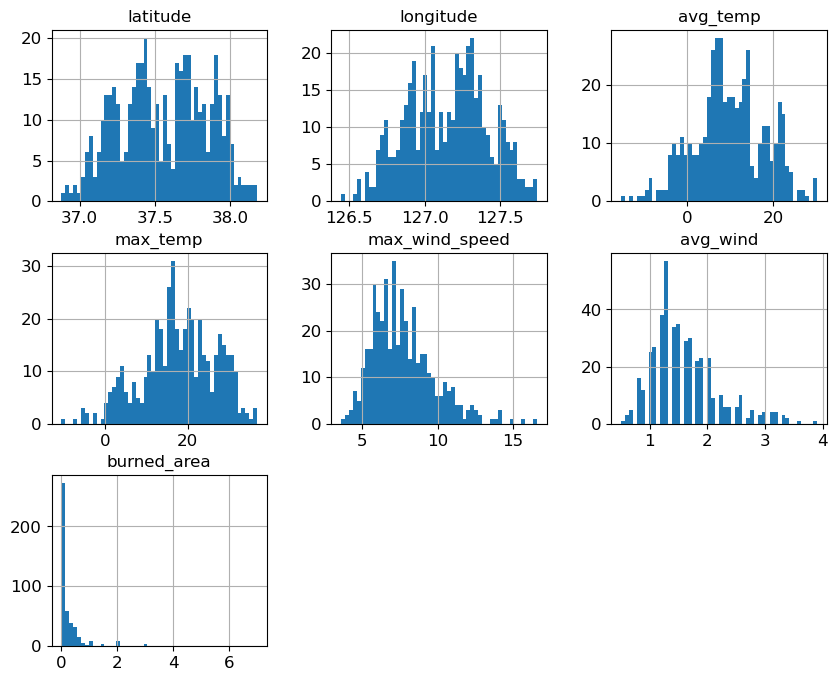

In [9]:
fires.hist(bins=50, figsize=(10, 8))
plt.show()

## 1-4 특성 burned_area 왜곡 현상(아래 왼쪽 그림) 개선을 위해 로그 함수(y=ln(burned_area+1))를 이용한 변환

In [10]:
fires["burned_area"] = np.log(fires["burned_area"] + 1)

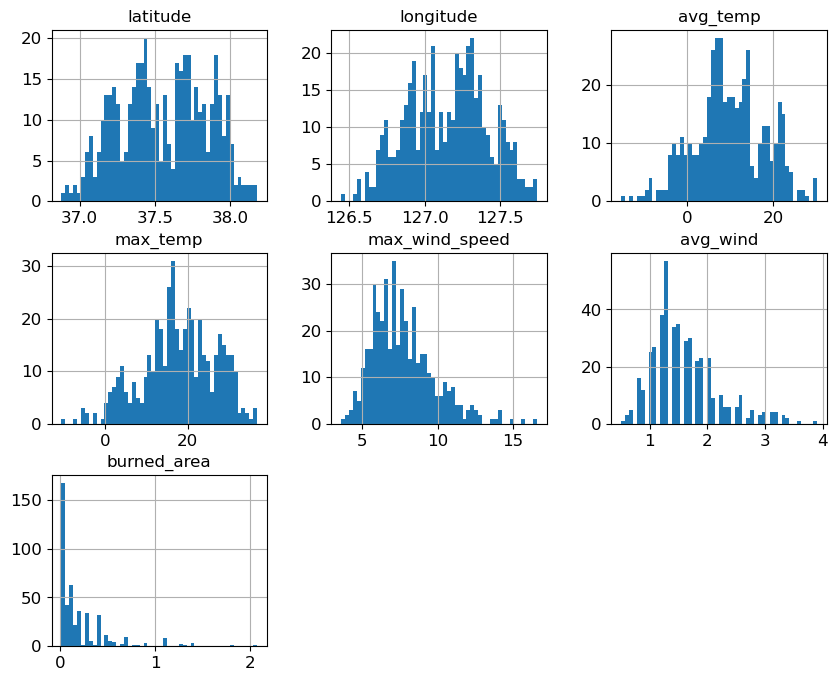

In [11]:
fires.hist(bins=50, figsize=(10, 8))
plt.show()

In [16]:
def bin_series_to_range(series, bins=7):
    min_val = series.min()
    max_val = series.max()
    bin_size = (max_val - min_val) / bins
    index = ((series - min_val) / bin_size).astype(int)
    index = index.clip(0, bins - 1)  # 0~6 보장
    return index + 1  # 1~7 범위로 맞추기

In [17]:
fires["longitude"] = bin_series_to_range(fires["longitude"])
fires["latitude"] = bin_series_to_range(fires["latitude"])

## 1-5 Scikit-Learn의 train_test_split을 이용하여 training/test set 분리 / Test set 비율 확인하기

In [20]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(fires, test_size=0.2, random_state=42)

In [21]:
train_set.head()

,latitude,longitude,month,day,avg_temp,max_temp,max_wind_speed,avg_wind,burned_area
17,5,6,03-Mar,05-fri,0.4,9.4,6.7,1.3,0.095310
66,2,6,03-Mar,03-wed,13.6,21.9,11.2,2.2,0.067659
305,3,5,06-Jun,03-wed,21.6,28.2,10.8,1.3,0.048790
411,2,2,03-Mar,05-fri,5.6,10.5,5.8,1.7,0.009950
31,4,6,03-Mar,03-wed,4.4,12.3,5.1,1.2,0.086178


<Axes: >

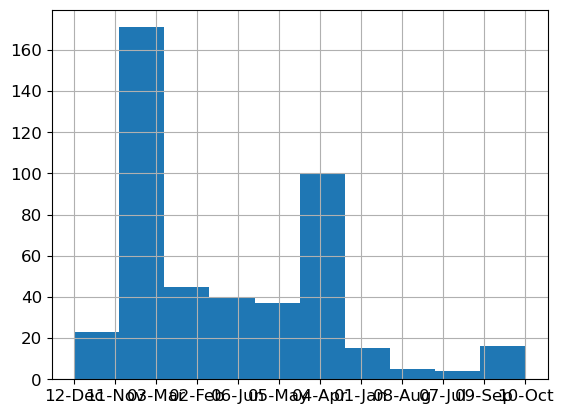

In [22]:
fires["month"].hist()

In [23]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(fires, fires["month"]):
    strat_train_set = fires.loc[train_index]
    strat_test_set = fires.loc[test_index]

print("\nMonth category proportion: \n",
      strat_test_set["month"].value_counts()/len(strat_test_set))

print("\nOverall month category proportion: \n",
      fires["month"].value_counts()/len(fires))


Month category proportion: 
 month
03-Mar    0.369565
04-Apr    0.217391
02-Feb    0.097826
06-Jun    0.086957
05-May    0.076087
11-Nov    0.032609
01-Jan    0.032609
09-Sep    0.021739
12-Dec    0.021739
10-Oct    0.021739
08-Aug    0.010870
07-Jul    0.010870
Name: count, dtype: float64

Overall month category proportion: 
 month
03-Mar    0.375000
04-Apr    0.219298
02-Feb    0.098684
06-Jun    0.087719
05-May    0.081140
01-Jan    0.032895
11-Nov    0.030702
12-Dec    0.019737
09-Sep    0.017544
10-Oct    0.017544
08-Aug    0.010965
07-Jul    0.008772
Name: count, dtype: float64


## 1-6 Pandas scatter_matrix() 함수를 이용하여 4개 이상의 특성에 대해 matrix 출력하기

array([[<Axes: xlabel='burned_area', ylabel='burned_area'>,
        <Axes: xlabel='max_temp', ylabel='burned_area'>,
        <Axes: xlabel='avg_temp', ylabel='burned_area'>,
        <Axes: xlabel='max_wind_speed', ylabel='burned_area'>],
       [<Axes: xlabel='burned_area', ylabel='max_temp'>,
        <Axes: xlabel='max_temp', ylabel='max_temp'>,
        <Axes: xlabel='avg_temp', ylabel='max_temp'>,
        <Axes: xlabel='max_wind_speed', ylabel='max_temp'>],
       [<Axes: xlabel='burned_area', ylabel='avg_temp'>,
        <Axes: xlabel='max_temp', ylabel='avg_temp'>,
        <Axes: xlabel='avg_temp', ylabel='avg_temp'>,
        <Axes: xlabel='max_wind_speed', ylabel='avg_temp'>],
       [<Axes: xlabel='burned_area', ylabel='max_wind_speed'>,
        <Axes: xlabel='max_temp', ylabel='max_wind_speed'>,
        <Axes: xlabel='avg_temp', ylabel='max_wind_speed'>,
        <Axes: xlabel='max_wind_speed', ylabel='max_wind_speed'>]],
      dtype=object)

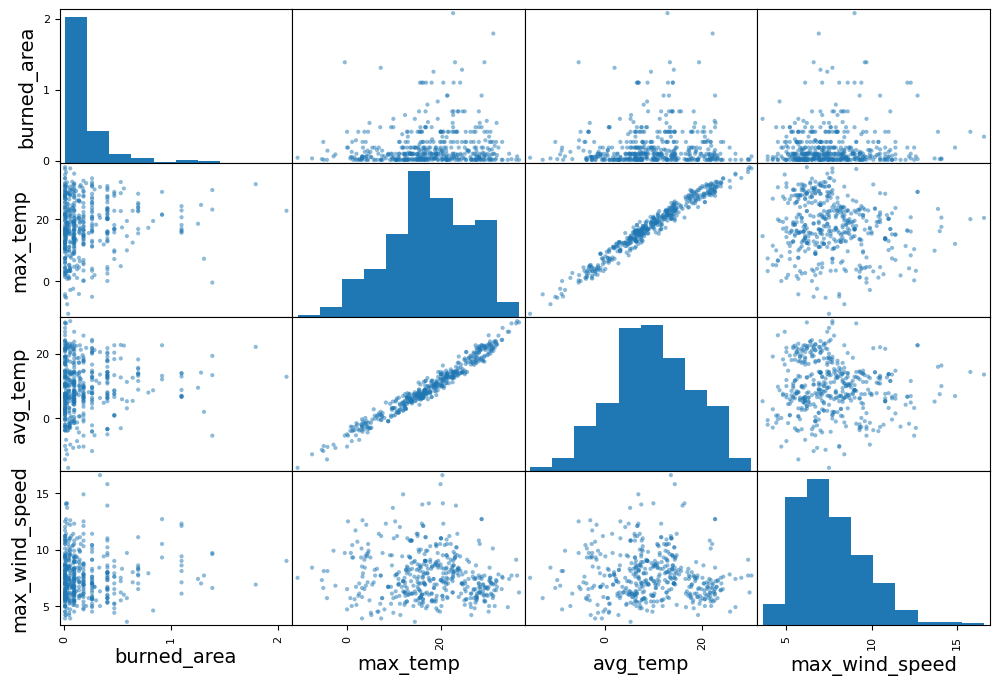

In [25]:
from pandas.plotting import scatter_matrix

attributes = ["burned_area", "max_temp", "avg_temp", "max_wind_speed"]
scatter_matrix(fires[attributes], figsize=(12, 8))

## 1-7 지역별로 ‘burned_area’에 대해 plot 하기: 원의 반경은 max_temp(옵션 s), 컬러는 burned_area(옵션 c)를 의미

/opt/anaconda3/envs/ai/lib/python3.10/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


<Axes: xlabel='longitude', ylabel='latitude'>

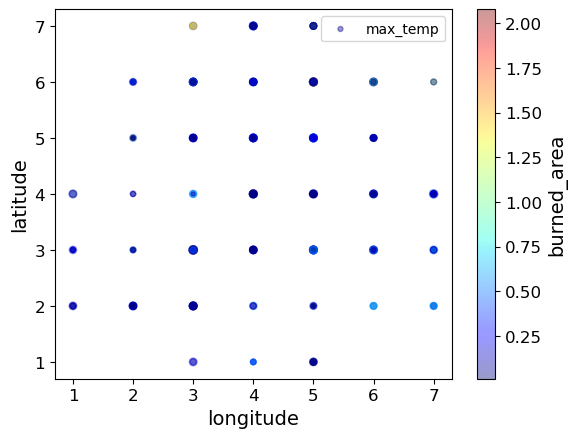

In [27]:
fires.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
           s=fires["max_temp"], label="max_temp",
           c="burned_area", cmap=plt.get_cmap("jet"), colorbar=True)

In [28]:
fires = strat_train_set.drop(["burned_area"], axis=1)
fires_labels = strat_train_set["burned_area"].copy()

In [29]:
fires_test = strat_test_set.drop(["burned_area"], axis=1)
fires_test_labels = strat_test_set["burned_area"].copy()

In [30]:
fires_labels

369    1.386294
118    0.262364
46     0.693147
95     0.641854
79     0.262364
         ...   
6      0.182322
336    0.039221
133    0.148420
182    0.148420
410    0.009950
Name: burned_area, Length: 364, dtype: float64

## 1-8 카테고리형 특성 month, day에 대해 OneHotEncoder()를 이용한 인코딩/출력

In [32]:
fires_num = fires.drop(["month", "day"], axis=1)

In [33]:
fires_num

,latitude,longitude,avg_temp,max_temp,max_wind_speed,avg_wind
369,7,3,13.4,23.1,9.6,1.5
118,3,5,24.4,33.2,7.6,1.0
46,5,4,11.6,16.8,11.1,2.6
95,5,6,12.6,22.7,8.0,1.4
79,6,4,3.2,12.5,5.9,1.1
...,...,...,...,...,...,...
6,6,6,17.8,27.6,5.8,1.2
336,6,4,12.6,23.0,9.2,1.8
133,2,3,12.5,17.2,9.9,3.1
182,2,3,0.6,6.4,8.3,1.7


In [34]:
cat_month = fires["month"].copy()
cat_day = fires["day"].copy()

In [35]:
cat_month

369    04-Apr
118    06-Jun
46     04-Apr
95     04-Apr
79     03-Mar
        ...  
6      05-May
336    03-Mar
133    03-Mar
182    03-Mar
410    03-Mar
Name: month, Length: 364, dtype: object

In [36]:
cat_day

369    05-fri
118    02-tue
46     03-wed
95     02-tue
79     03-wed
        ...  
6      02-tue
336    05-fri
133    02-tue
182    03-wed
410    02-tue
Name: day, Length: 364, dtype: object

In [37]:
from sklearn.preprocessing import OneHotEncoder
cat_month_encoder = OneHotEncoder()
month_cat_1hot = cat_month_encoder.fit_transform(cat_month.values.reshape(-1, 1))

In [38]:
cat_month_encoder.categories_

[array(['01-Jan', '02-Feb', '03-Mar', '04-Apr', '05-May', '06-Jun',
        '07-Jul', '08-Aug', '09-Sep', '10-Oct', '11-Nov', '12-Dec'],
       dtype=object)]

In [39]:
month_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 364 stored elements and shape (364, 12)>

In [40]:
cat_day_encoder = OneHotEncoder()
day_cat_1hot = cat_day_encoder.fit_transform(cat_day.values.reshape(-1, 1))

In [41]:
cat_day_encoder.categories_

[array(['00-sun', '01-mon', '02-tue', '03-wed', '04-thu', '05-fri',
        '06-sat', '07-hol'], dtype=object)]

In [42]:
day_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 364 stored elements and shape (364, 8)>

## 1-9 Scikit-Learn의 Pipeline, StandardScaler를 이용하여 카테고리형 특성을 인코딩한 training set 생성하기

In [44]:
print("\n\n########################################################")
print("Now let's build a pipeline for preprocessing the numerical attributes:")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

num_attribs = fires_num.columns.tolist()
cat_attribs = ["month", "day"]

num_pipeline = Pipeline([
    ('std_scaler', StandardScaler()),
])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

fires_prepared = full_pipeline.fit_transform(fires)
fires_test_prepared = full_pipeline.transform(fires_test)



########################################################
Now let's build a pipeline for preprocessing the numerical attributes:


In [45]:
import tensorflow as tf
from tensorflow import keras

# Keras model 개발
X_train, X_valid, y_train, y_valid = train_test_split(fires_prepared, fires_labels, test_size=0.2, random_state=42)
X_test, y_test = fires_test_prepared, fires_test_labels

np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Dense(30, activation='relu', input_shape =X_train.shape[1:]),
    keras.layers.Dense(30, activation='relu', input_shape =X_train.shape[1:]),
    keras.layers.Dense(30, activation='relu', input_shape =X_train.shape[1:]),
    keras.layers.Dense(1)
])

model.summary()

model.compile(loss='mean_squared_error', optimizer=keras.optimizers.SGD(learning_rate=1e-3))
history = model.fit(X_train, y_train, epochs=200, validation_data=(X_valid, y_valid))

# Keras 모델 저장
model.save('fires_model.keras')

# evaluate model
X_new = X_test[:3]
print("\nnp.round(model.predict(X_new), 2): \n",
      np.round(model.predict(X_new), 2))

/opt/anaconda3/envs/ai/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           810 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,701 (10.55 KB)

 Trainable params: 2,701 (10.55 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0883 - val_loss: 0.0861
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0875 - val_loss: 0.0858
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0869 - val_loss: 0.0855
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0863 - val_loss: 0.0852
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0857 - val_loss: 0.0850
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0852 - val_loss: 0.0848
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0847 - val_loss: 0.0845
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0843 - val_loss: 0.0843
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0839 - val_loss: 0.0840
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0835 - val_loss: 0.0838
Epoch 11/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0831 - val_loss: 0.0836
Epoch 12/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0